# Projekt Waldbrand

### Gruppe 5

#### Mitglieder:

Korbinian Haberstetter,
Ilan Wiesner,
Tilman Patzak

In [1]:
# print out each line in the input cell not only the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# expand the cell width to 100% of the content
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

## Aufgabe1 (+ pBlitz Aufgabe 3)

In [4]:
import copy
from sage.misc.prandom import random

# generates a forest with given size and given poisition of fire
def generate_forest_by_position(size, *positions):
    forest =  [[0 if i == 0 or i == size - 1 or j == 0 or j == size-1 else 1 for j in range(size)] for i in range(size)]
    for x, y in positions:
        if (x < 0 or x >= size - 2 or y < 0 or y >= size - 2):
            raise Exception(illegalArgument)
        forest[x + 1][y + 1] = 2
    return forest

# generates a forest with given size and random poisition of fire
def generate_forest_by_random(size, fire):
    forest =  [[0 if i == 0 or i == size - 1 or j == 0 or j == size-1 else 1 for j in range(size)] for i in range(size)]
    for f in range(fire):
        forest[randint(1, size - 2)][randint(1, size - 2)] = 2
    return forest

# takes a forest and calculates the next phase with given possibility of fire next to the given fire and possibility that thunder strikes
def burning_forest(forest, p_e, p_blitz):
    new_forest = copy.deepcopy(forest)
    for row in range(len(forest)):
        for entry in range(len(forest[row])): 
            if (forest[row][entry] == 0):
                new_forest[row][entry] = 0
            elif (forest[row][entry] == 1):
                new_forest[row][entry] = 2 if random() < p_blitz else new_forest[row][entry] #Possibility that thunder strikes
                if (forest[row - 1][entry] == 2 or forest[row + 1][entry] == 2 or forest[row][entry - 1] == 2 or forest[row][entry + 1] == 2): # checks if any neighbourfields burn
                    new_forest[row][entry] = 2 if random() < p_e else new_forest[row][entry]
            elif (forest[row][entry] == 2):
                new_forest[row][entry] = 0
    return new_forest

# Animates the forest and returns the last maxtrix for a given time
def burning_simulation(forest, p_e, p_blitz, t):
    matrix_list = []
    matrix_list.append(forest)
    new_forest = burning_forest(forest, p_e, p_blitz)
    matrix_list.append(new_forest)
    for i in range(t - 1):
        new_forest = burning_forest(new_forest, p_e, p_blitz)
        matrix_list.append(new_forest)
    return matrix_list

def animate_and_plot_simulation(matrix_list):
    plots = []
    for forest in matrix_list:
        plots.append(matrix_plot(forest, cmap=["white", "green", "#fc1605", "#f5655b", "#ffc6bf"], colorbar=False, vmin=0, vmax=4))
    animation = animate(plots)
    animation.show()

#animate_and_plot_simulation(burning_simulation(generate_forest_by_random(10, 1), 0.5, 0.01, 24))


#matrix with fire in center
forest_center_fire = generate_forest_by_position(9, (3,3))

#matrix with several parts on fire
forest_several_points = generate_forest_by_position(9, (1,1) , (4,2), (5,3))

## Aufgabe 2

Animation with 25 frames
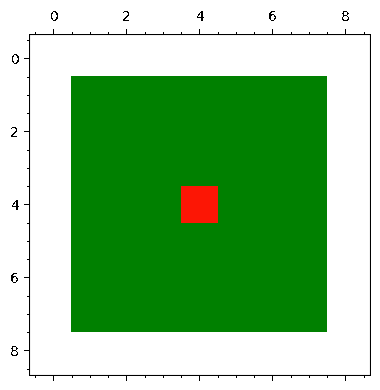

Animation with 25 frames
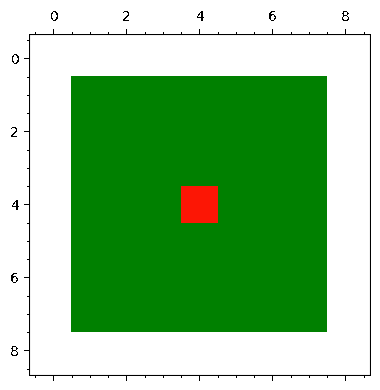

Animation with 25 frames
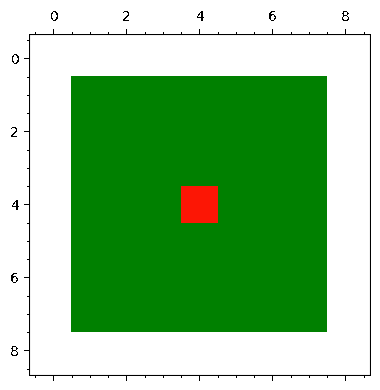

In [5]:
#animates 3 animations with probabilities of 0.2, 0.5 and 0.8 of the fire spreading without lightning strikes

animate_and_plot_simulation(burning_simulation(forest_center_fire, 0.2, 0, 24))
animate_and_plot_simulation(burning_simulation(forest_center_fire, 0.5, 0, 24))
animate_and_plot_simulation(burning_simulation(forest_center_fire, 0.8, 0, 24))

In [4]:
#gibt Prozent des abgebrannten Waldes an
def burnedperc(matrix):

    burnt = 0
    entries = 0
    
    for i in range(1, len(matrix)-1):      # Erste und letzte Zeile überspringen
        for j in range(1, len(matrix)-1):  # Erste und letzte Spalte überspringen
            entries += 1
            if matrix[i][j] == 0:
                burnt += 1
    return burnt / entries


matrix1 = generate_forest_by_random(25, 3)
list_of_matrizes = burning_simulation(matrix1, 0.2, 0.001, 50)
test = N(burnedperc(list_of_matrizes[len(list_of_matrizes)-1]))
print(f"Prozent der 'abgebrannten' (2er) Einträge: {test}")

Prozent der 'abgebrannten' (2er) Einträge: 0.136105860113422


In [14]:
# calculates the average of how much burned over several simulation for testing

forest_for_tests = generate_forest_by_random(25, 5)

def average_perc_over_simulations(forest, p_e, p_blitz, t, runs):
    total_zeros = 0
    burned_perc = 0
    for _ in range(runs):
        
        all_matrix = burning_simulation(forest, p_e, p_blitz, t)
        final_matrix = all_matrix[len(all_matrix)-1]
        burned_perc += burnedperc(final_matrix)

    average_percent = burned_perc / runs


    return average_percent

#average at zero probalility
n(average_perc_over_simulations(forest_for_tests, 0 ,0 , 50, 30))

#average at low probability
n(average_perc_over_simulations(forest_for_tests, 0.2 ,0 , 50, 30))

#average at medium probability
n(average_perc_over_simulations(forest_for_tests, 0.5, 0, 50, 30))

#average at high probability
n(average_perc_over_simulations(forest_for_tests, 0.8, 0, 50, 30))


0.00945179584120983

0.0225582860743541

0.464902331442974

0.969502205419030

## Aufgabe 3

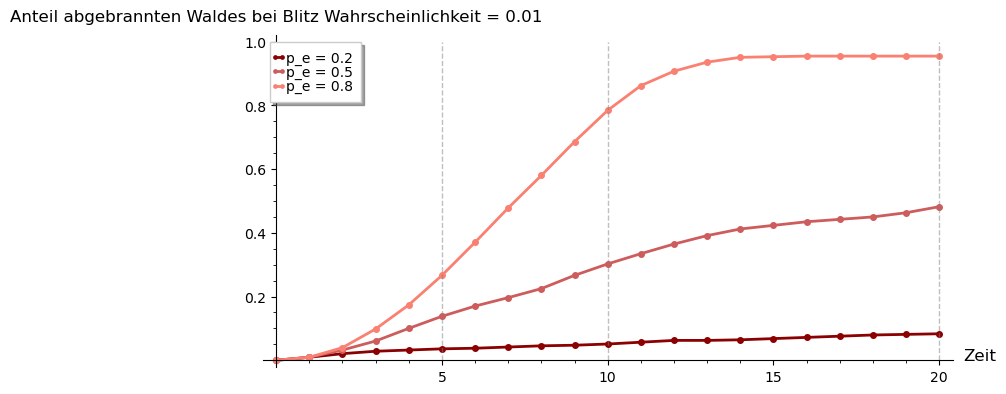

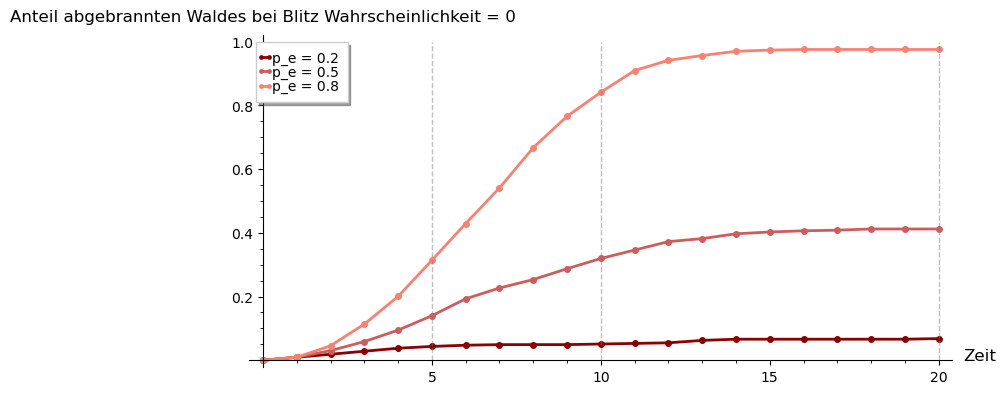

In [13]:
# function to calculate the part of burned forest
# returns points for plotting the function

def list_amount_of_burned_forest(forest, p_e, p_blitz, t):
    matrizen = burning_simulation(forest, p_e, p_blitz, t)
    werte = [burnedperc(M) for M in matrizen]
    punkte = [(i, y) for i, y in enumerate(werte)]
    
    return punkte

forest_for_plot = generate_forest_by_random(25, 5)

set_verbose(-1)
plot1 = list_plot(list_amount_of_burned_forest(forest_for_plot, 0.2, 0.001, 20), 
                  plotjoined=True, marker='o', markersize=4, color='darkred', thickness=2, legend_label='p_e = 0.2')
plot2 = list_plot(list_amount_of_burned_forest(forest_for_plot, 0.5, 0.001, 20), color = 'indianred',
                  plotjoined=True, marker='o', markersize=4, thickness=2, legend_label='p_e = 0.5')
plot3 = list_plot(list_amount_of_burned_forest(forest_for_plot, 0.8, 0.001, 20), color = 'salmon', 
                 plotjoined=True, marker='o', markersize=4, thickness=2, legend_label='p_e = 0.8')

# lines at t=5, 10, 20 
vertical_lines = sum(line([(t, 0), (t, 1)], color='gray', linestyle='--', alpha=0.5) for t in [5, 10, 20])

gesamtplot = plot1 +plot2 + plot3 + vertical_lines
gesamtplot.axes_labels(["Zeit", "Anteil abgebrannten Waldes bei Blitz Wahrscheinlichkeit = 0.01"])
gesamtplot.axes_labels_size(1.2)
show(gesamtplot, figsize=(10, 4))


set_verbose(-1)
plot1 = list_plot(list_amount_of_burned_forest(forest_for_plot, 0.2, 0.001, 20), 
                  plotjoined=True, marker='o', markersize=4, color='darkred', thickness=2, legend_label='p_e = 0.2')
plot2 = list_plot(list_amount_of_burned_forest(forest_for_plot, 0.5, 0.001, 20), color = 'indianred',
                  plotjoined=True, marker='o', markersize=4, thickness=2, legend_label='p_e = 0.5')
plot3 = list_plot(list_amount_of_burned_forest(forest_for_plot, 0.8, 0.001, 20), color = 'salmon', 
                 plotjoined=True, marker='o', markersize=4, thickness=2, legend_label='p_e = 0.8')
gesamtplot = plot1 +plot2 + plot3 + vertical_lines
gesamtplot.axes_labels(["Zeit", "Anteil abgebrannten Waldes bei Blitz Wahrscheinlichkeit = 0"],)
gesamtplot.axes_labels_size(1.2)
show(gesamtplot,figsize=(10, 4))

## Aufgabe 4

In [ ]:
# Does the same like burning_forest before, but with rising number of fires next to a field, the possibility that the field also burns rises
def burning_forest_variable(forest, p_e, p_blitz):
    new_forest = copy.deepcopy(forest)
    for row in range(len(forest)):
        for entry in range(len(forest[row])):
            if (forest[row][entry] == 0):
                new_forest[row][entry] = 0
            elif (forest[row][entry] == 1):
                new_forest[row][entry] = 2 if random() <= p_blitz else new_forest[row][entry] # Possibility that thunder strikes
                if (forest[row - 1][entry] == 2):                                            # Checks every neighbour if it burns -> Rising possibility with rising number of burning neighbours
                    new_forest[row][entry] = 2 if random() <= p_e else new_forest[row][entry]
                if (forest[row + 1][entry] == 2):
                    new_forest[row][entry] = 2 if random() <=p_e else new_forest[row][entry]
                if (forest[row][entry - 1] == 2):
                    new_forest[row][entry] = 2 if random() <=p_e else new_forest[row][entry]
                if (forest[row][entry + 1] == 2):
                    new_forest[row][entry] = 2 if random() <=p_e else new_forest[row][entry]
            elif (forest[row][entry] == 2):
                new_forest[row][entry] = 0
    return new_forest

# Animates the forest and returns the last maxtrix for a given time
def burning_simulation_variable(forest, p_e, p_blitz, t):
    matrix_list = []
    matrix_list.append(forest)
    new_forest = burning_forest_variable(forest, p_e, p_blitz)
    matrix_list.append(new_forest)
    for i in range(t - 1):
        new_forest = burning_forest_variable(new_forest, p_e, p_blitz)
        matrix_list.append(new_forest)
    return matrix_list

animate_and_plot_simulation(burning_simulation_variable(generate_forest_by_random(10, 1), 0.5, 0.01, 24))

## Aufgabe 5


In [ ]:
# Does the same like the first burning_forest, but a field burns now 3 times in a row
def burning_forest_3(forest, p_e, p_blitz):
    new_forest = copy.deepcopy(forest)
    for row in range(len(forest)):
        for entry in range(len(forest[row])):
            if (forest[row][entry] == 0):
                new_forest[row][entry] = 0
            elif (forest[row][entry] == 1):
                new_forest[row][entry] = 2 if random() < p_blitz else new_forest[row][entry] #Possibility that thunder strikes
                if (forest[row - 1][entry] >= 2 or forest[row + 1][entry] >= 2 or forest[row][entry - 1] >= 2 or forest[row][entry + 1] >= 2):
                    new_forest[row][entry] = 2 if random() < p_e else new_forest[row][entry]
            elif (forest[row][entry] == 2): # 3 existing states of burning
                new_forest[row][entry] = 3
            elif (forest[row][entry] == 3):
                new_forest[row][entry] = 4
            elif (forest[row][entry] == 4):
                new_forest[row][entry] = 0
    return new_forest

# Animates the forest and returns the last maxtrix for a given time
def burning_simulation_3(forest, p_e, p_blitz, t):
    matrix_list = []
    matrix_list.append(forest)
    new_forest = burning_forest_3(forest, p_e, p_blitz)
    matrix_list.append(new_forest)
    for i in range(t - 1):
        new_forest = burning_forest_3(new_forest, p_e, p_blitz)
        matrix_list.append(new_forest)
    return matrix_list

animate_and_plot_simulation(burning_simulation_3(generate_forest_by_random(10, 1), 0.5, 0.01, 24))

## Aufgabe 6

In [ ]:
# Does the same like burning_forest_variable, but takes wind_level and wind_direction. 
# Level 0 -> direct neighbours in all directions can burn
# Level 1 -> for example, if wind_direction is north, only a field north to a burning field can burn
# Level 2 -> for example, if wind_direction is north, up two fields north to a burning field can burn
def burning_forest_wind(forest, p_e, p_blitz, wind_level, wind_direction):
    new_forest = copy.deepcopy(forest)
    for row in range(len(forest)):
        for entry in range(len(forest[row])):
            if (forest[row][entry] == 0):
                new_forest[row][entry] = 0
            elif (forest[row][entry] == 1):
                new_forest[row][entry] = 2 if random() < p_blitz else new_forest[row][entry] #Possibility that thunder strikes
                if (forest[row - 1][entry] == 2 and (wind_direction == 's' or wind_level == 0)): # At Level 0 checks every neighbour if it burns -> Rising possibility with rising number of burning neighbours, at Level 1 only field in opposide wind direction, at Level 2 two fields in opposide wind direction 
                    new_forest[row][entry] = 2 if random() < p_e else new_forest[row][entry]
                if (wind_level == 2 and forest[max(row - 2, 0)][entry] == 2 and wind_direction == 's'):
                    new_forest[row][entry] = 2 if random() < p_e else new_forest[row][entry]

                    
                if (forest[row + 1][entry] == 2 and (wind_direction == 'n' or wind_level == 0)):
                    new_forest[row][entry] = 2 if random() < p_e else new_forest[row][entry]
                if (wind_level == 2 and forest[min(row + 2, len(forest) - 1)][entry] == 2 and wind_direction == 'n'):
                    new_forest[row][entry] = 2 if random() < p_e else new_forest[row][entry]

                    
                if (forest[row][entry - 1] == 2 and (wind_direction == 'e' or wind_level == 0)):
                    new_forest[row][entry] = 2 if random() < p_e else new_forest[row][entry]
                if (wind_level == 2 and forest[row][max(entry - 2, 0)] == 2 and wind_direction == 'e'):
                    new_forest[row][entry] = 2 if random() < p_e else new_forest[row][entry]

                    
                if (forest[row][entry + 1] == 2 and (wind_direction == 'w' or wind_level == 0)):
                    new_forest[row][entry] = 2 if random() < p_e else new_forest[row][entry]
                if (wind_level == 2 and forest[row][min(entry + 2, len(forest[row]) - 1)] == 2 and wind_direction == 'w'):
                    new_forest[row][entry] = 2 if random() < p_e else new_forest[row][entry]

                    
            elif (forest[row][entry] == 2):
                new_forest[row][entry] = 0
    return new_forest

# Animates the forest and returns the last maxtrix for a given time
def burning_simulation_wind(forest, p_e, p_blitz, wind_level, wind_direction, t):
    matrix_list = []
    matrix_list.append(forest)
    new_forest = burning_forest_wind(forest, p_e, p_blitz, wind_level, wind_direction)
    matrix_list.append(new_forest)
    for i in range(t - 1):
        new_forest = burning_forest_wind(new_forest, p_e, p_blitz, wind_level, wind_direction)
        matrix_list.append(new_forest)
    return matrix_list

animate_and_plot_simulation(burning_simulation_wind(generate_forest_by_random(10,1 ), 0.5, 0.00, 2, "e", 24))